# Mini Project – Data Wrangling & Operational Analysis(Austin Bikeshare Business Case)

## 💾 The data: [austin_bikeshare_trips.csv](https://drive.google.com/file/d/1pJObis36buPaW4bP_PkamXkBwlBr7Jl_/view)

##### **Business Case** :
The Austin Transportation Department is reviewing operational efficiency for the city's bikeshare program. Complaints have increased regarding ***bike availability***, ***long trip durations***, and ***inconsistent station performance***. Before expanding stations or adjusting operations, the city needs clean, reliable data to understand rider behavior and station efficiency.

##### **Project Goal** :
Perform an end-to-end data wrangling workflow to produce a clean dataset suitable for operational decision‑making.

## 1. Data Wrangling 

In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Load and Inspect

In [3]:
# Load the Dataset

# Read the csv file into a pandas DataFrame
df = pd.read_csv('austin_bikeshare_trips.csv')

print('Data loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Data loaded successfully!
Shape: 50000 rows x 10 columns


In [4]:
# Inspect the data

# View the first few rows to understand the structure
df.head(10)

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
0,19309516,Single Trip,647,classic,2019-02-24 09:32:17 UTC,4051.0,10th & Red River,4051.0,10th & Red River,12
1,19309511,Single Trip,12802,classic,2019-02-24 09:31:03 UTC,4051.0,10th & Red River,4051.0,10th & Red River,8
2,19309522,Single Trip,046G,classic,2019-02-24 09:34:16 UTC,4051.0,10th & Red River,4051.0,10th & Red River,11
3,19346245,Local30,263G,classic,2019-03-08 07:37:03 UTC,4051.0,10th & Red River,4051.0,10th & Red River,50
4,19468664,24 Hour Walk Up Pass,2143,classic,2019-03-31 12:16:21 UTC,4051.0,10th & Red River,4051.0,10th & Red River,267
5,19468668,24 Hour Walk Up Pass,1782,classic,2019-03-31 12:16:58 UTC,4051.0,10th & Red River,4051.0,10th & Red River,268
6,19468669,24 Hour Walk Up Pass,174,classic,2019-03-31 12:17:26 UTC,4051.0,10th & Red River,4051.0,10th & Red River,267
7,19390778,Single Trip Ride,874,classic,2019-03-17 10:49:45 UTC,4051.0,10th & Red River,4051.0,10th & Red River,37
8,19378857,U.T. Student Membership,864,classic,2019-03-14 19:07:54 UTC,4051.0,10th & Red River,4051.0,10th & Red River,25
9,19390779,Single Trip Ride,2286,classic,2019-03-17 10:49:46 UTC,4051.0,10th & Red River,4051.0,10th & Red River,37


In [5]:
# View data types and non-null count for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trip_id             50000 non-null  int64  
 1   subscriber_type     49808 non-null  object 
 2   bike_id             50000 non-null  object 
 3   bike_type           50000 non-null  object 
 4   start_time          50000 non-null  object 
 5   start_station_id    49983 non-null  float64
 6   start_station_name  50000 non-null  object 
 7   end_station_id      49191 non-null  float64
 8   end_station_name    50000 non-null  object 
 9   duration_minutes    50000 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 3.8+ MB


In [6]:
# View statistical summary of the numeric columns
df.describe()

,trip_id,start_station_id,end_station_id,duration_minutes
count,5.000000e+04,49983.000000,49191.000000,50000.000000
mean,2.061512e+07,3230.491787,3361.201053,38.735440
std,9.132965e+06,1027.225877,1144.490004,197.530166
min,1.954839e+06,1007.000000,2494.000000,2.000000
25%,1.612823e+07,2539.000000,2497.000000,8.000000
50%,2.366079e+07,2570.000000,2561.000000,16.000000
75%,2.722677e+07,3797.000000,4051.000000,34.000000
max,3.386933e+07,7637.000000,7341.000000,19669.000000


In [7]:
# Check for duplicate rows in the dataset
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


In [8]:
# Inspect station names 

print(f'Number of unique start station names: {df['start_station_name'].nunique()}\n')

# View unique start station names in detail(first 50 rows)
df['start_station_name'].unique()[:50]

Number of unique start station names: 184



array(['10th & Red River', '11th & Salina ', '11th & San Jacinto',
       '13th & San Antonio', '17th & Guadalupe', '21st & Speedway @PCL',
       '21st & University', '3rd & West', '4th & Congress',
       '5th & Campbell', '6th & Chalmers ', '6th & Congress',
       '8th & Congress', 'Barton Springs & Riverside',
       'Barton Springs @ Kinney Ave', 'Barton Springs Pool',
       'Boardwalk West', 'Brazos & 6th',
       'Capitol Station / Congress & 11th', 'City Hall / Lavaca & 2nd',
       'Congress & Cesar Chavez', 'Convention Center / 3rd & Trinity',
       'Convention Center / 4th St. @ MetroRail',
       'Davis at Rainey Street', 'Dean Keeton & Speedway ',
       'East 11th St. & San Marcos', 'East 11th St. at Victory Grill',
       'East 6th & Pedernales St.', 'East 6th at Robert Martinez',
       'Guadalupe & 21st', 'Lakeshore @ Austin Hostel',
       'Long Center @ South 1st & Riverside', 'Medina & East 6th',
       'Palmer Auditorium', 'Pfluger Bridge @ W 2nd Street',
      

In [9]:
print(f'Number of unique end station names: {df['end_station_name'].nunique()}\n')

# View unique end station names
df['end_station_name'].unique()

Number of unique end station names: 17



array(['10th & Red River', '10th/Red River', '11th & Salina ',
       '11th & San Jacinto', '11th/Congress @ The Texas Capitol',
       '11th/Salina', '11th/Salina ', '11th/San Jacinto',
       '12th/San Jacinto @ State Capitol Visitors Garage',
       '13th & San Antonio', '13th/San Antonio', '13th/Trinity',
       '13th/Trinity @ Waterloo Greenway', '16th/San Antonio',
       '17th & Guadalupe', '17th/Guadalupe', '21st & Speedway @PCL'],
      dtype=object)

**Issues Identified**
- Missing Values: There are missing values in the `subscriber_type`, `start_station_id` and `end_station_id` columns.

- Incorrect Data Types: The `start_time`, `start_station_id` and `end_station_id` values are stored as the wrong data types.

- Unusual trip durations: The min and max  values of the `duration_minutes` column are unusual with the max trip being  19669 minutes(approx. 14 days).

- Inconsistent formatting: The `start_station_name` and `end_station_name` values  contains symbols, additional whitespace characters and abbreviations that are inconsistent.

### 1.2 Handle Missing & Inconsistent Values

In [10]:
# View missing values in detail

print(f"Number of rows in dataframe: {len(df)}\n")

missing_count = df.isnull().sum()   # count of missing value in each column
missing_percent = df.isnull().sum() / len(df) * 100   # percent of missing values in each column

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing_Count'] > 0])

Number of rows in dataframe: 50000

                  Missing_Count  Percentage
subscriber_type             192       0.384
start_station_id             17       0.034
end_station_id              809       1.618


#### 1.2.1 Handle Missing Station IDs

**Business Problem**: The city cannot track station performance with incomplete station metrics.

In [11]:
# Examine rows with missing values

df.loc[
    df['start_station_id'].isnull(),     # rows with missing start station id
    ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name']  # columns of interest
]

,start_station_id,start_station_name,end_station_id,end_station_name
10292,NaN,Ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage
14053,NaN,Springfest 2022,4879.0,16th/San Antonio
15705,NaN,Repair Shop,2540.0,17th/Guadalupe
18283,NaN,Dean Keeton & Speedway,3291.0,11th & San Jacinto
18284,NaN,Dean Keeton & Speedway,3291.0,11th & San Jacinto
21491,NaN,Dean Keeton & Speedway,3635.0,13th & San Antonio
21492,NaN,Dean Keeton & Speedway,3635.0,13th & San Antonio
21493,NaN,Dean Keeton & Speedway,3635.0,13th & San Antonio
21494,NaN,Dean Keeton & Speedway,3635.0,13th & San Antonio
21495,NaN,Dean Keeton & Speedway,3635.0,13th & San Antonio


In [12]:
df.loc[
    df['end_station_id'].isnull(),     # rows with missing start station id
    ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name']  # columns of interest
].head(20)

,start_station_id,start_station_name,end_station_id,end_station_name
13037,2552.0,3rd/West,NaN,16th/San Antonio
24599,4051.0,10th/Red River,NaN,10th/Red River
24600,4051.0,10th/Red River,NaN,10th/Red River
24601,4051.0,10th/Red River,NaN,10th/Red River
24602,4051.0,10th/Red River,NaN,10th/Red River
24603,4051.0,10th/Red River,NaN,10th/Red River
24687,2497.0,11th/Congress @ The Texas Capitol,NaN,10th/Red River
24751,2547.0,21st/Guadalupe,NaN,10th/Red River
24761,3798.0,21st/Speedway @ PCL,NaN,10th/Red River
24762,3798.0,21st/Speedway @ PCL,NaN,10th/Red River


**Observations**
- Station names are all present in rows with missing Station IDs.
- Some stations with the same `start_station_name` and `end_station_name` have intact `start_station_id` but missing `end_station_id`.

**Wrangling Decision**
- Create a custom function, to standardize separators (/, &, -) and remove inconsistent spacing.
- Create a reference dictionary of unique station names and IDs and use it to impute values for missing station IDs rather than deleting records with missing IDs to preserve valuable trip data.

In [13]:
# Create copy of DataFrame before cleaning
df_1 = df.copy()

print('Data copied successfully!')
print(f'Shape: {df_1.shape[0]} rows x {df_1.shape[1]} columns')

Data copied successfully!
Shape: 50000 rows x 10 columns


In [14]:
# Temporarily raise the row limit to be able to view all rows
pd.set_option('display.max_rows', None)

In [15]:
# View all unique_start_staion_name and their corresponding ID
df_1[['start_station_id', 'start_station_name']].drop_duplicates().sort_values(by='start_station_id') 

,start_station_id,start_station_name
1937,1007.0,Lavaca & 6th
1970,1008.0,Nueces @ 3rd
1266,2494.0,2nd & Congress
385,2494.0,2nd/Congress
40,2495.0,4th & Congress
474,2495.0,4th/Congress
45,2496.0,8th & Congress
567,2496.0,8th/Congress
220,2497.0,11th/Congress @ The Texas Capitol
56,2497.0,Capitol Station / Congress & 11th


In [16]:
# View all unique end_staion_names and their corresponding ID
df_1[['end_station_id', 'end_station_name']].drop_duplicates().sort_values(by='end_station_id')

,end_station_id,end_station_name
3673,2494.0,11th/Congress @ The Texas Capitol
13093,2495.0,16th/San Antonio
4069,2495.0,11th/Congress @ The Texas Capitol
6487,2495.0,11th/Salina
478,2495.0,10th/Red River
9857,2495.0,12th/San Jacinto @ State Capitol Visitors Garage
4623,2496.0,11th/Congress @ The Texas Capitol
10018,2496.0,12th/San Jacinto @ State Capitol Visitors Garage
41205,2496.0,10th/Red River
13366,2496.0,16th/San Antonio


In [17]:
# Create a function to clean station names

def clean_station_names(series):
    '''
    This function takes a pandas series of station names,
    converts all names to lowercase,
    replaces symbols,
    removes leading/trailing spaces ,
    removes double spaces and 
    standardizes abbreviations
    
    '''
    
    series = series.str.lower()
    
    series = series.str.replace('/', ' and ', regex=False)
    series = series.str.replace('&', ' and ', regex=False)
    series = series.str.replace('@', ' at ', regex=False)
    series = series.str.replace('-', ' ', regex=False)
    
    series = series.str.strip()

    series = series.str.replace(r'\s+', ' ', regex=True)

    series = series.str.replace(' st.', ' street', regex=False)
    series = series.str.replace(' st$', ' street ', regex=True)

   
    return series

##### Clean Start Station Names

In [18]:
# Apply function to start_station_name column
df_1['start_station_name'] = clean_station_names(
    df_1['start_station_name']
)

In [19]:
# View changes
df_1[['start_station_id', 'start_station_name']].drop_duplicates().sort_values(by='start_station_id') 

,start_station_id,start_station_name
1937,1007.0,lavaca and 6th
1970,1008.0,nueces at 3rd
385,2494.0,2nd and congress
40,2495.0,4th and congress
45,2496.0,8th and congress
220,2497.0,11th and congress at the texas capitol
56,2497.0,capitol station and congress and 11th
662,2498.0,dean keeton and speedway
61,2498.0,convention center and 4th street at metrorail
402,2499.0,2nd and lavaca at city hall


**Observation**

After removing symbols and spacing, there are still inconsistent naming(rearranged words) which is resulting in different variation of names sharing the same ID (e.g, 2nd and lava at city hall/city hall and lavaca and 2nd, west and 6th street/6th and west).

**Wrangling Decision**

Assign `start_station id` to its most frequent name value and then create dictionary with unique station names and corresponding ID and use it to impute values for missing station IDs

In [20]:
# View the variations of names for each start_station_id(excluding nulls) and their counts
df_1.dropna(subset=['start_station_id']).groupby('start_station_id')['start_station_name'].value_counts()

start_station_id  start_station_name                                                
1007.0            lavaca and 6th                                                          52
1008.0            nueces at 3rd                                                            4
2494.0            2nd and congress                                                      1258
2495.0            4th and congress                                                      1185
2496.0            8th and congress                                                      1158
2497.0            11th and congress at the texas capitol                                4185
                  capitol station and congress and 11th                                  271
2498.0            dean keeton and speedway                                               772
                  convention center and 4th street at metrorail                          223
2499.0            2nd and lavaca at city hall                                 

In [21]:
# Create a reference table to map each id to most frequent name value
id_to_name_map = df_1.dropna(subset=['start_station_id']).groupby('start_station_id')['start_station_name'].agg(lambda x: x.mode()[0])
id_to_name_map

start_station_id
1007.0                                       lavaca and 6th
1008.0                                        nueces at 3rd
2494.0                                     2nd and congress
2495.0                                     4th and congress
2496.0                                     8th and congress
2497.0               11th and congress at the texas capitol
2498.0                             dean keeton and speedway
2499.0                          2nd and lavaca at city hall
2500.0                                      republic square
2501.0                                        5th and bowie
2502.0                         barton springs and riverside
2503.0                             south congress and james
2504.0                         south congress and elizabeth
2536.0                                waller and 6th street
2537.0                                         6th and west
2538.0                   bullock museum at congress and mlk
2539.0             3rd 

In [22]:
# Standardize start_station_name by mapping IDs to the most frequent names contained in the reference table
df_1['start_station_name'] = (
    df_1['start_station_id'].map(id_to_name_map)
    .fillna(df_1['start_station_name'])         # fill names that have null ids with their original names
)

In [23]:
# View the changes
df_1[['start_station_id', 'start_station_name']].drop_duplicates().sort_values(by='start_station_id') 

,start_station_id,start_station_name
1937,1007.0,lavaca and 6th
1970,1008.0,nueces at 3rd
385,2494.0,2nd and congress
40,2495.0,4th and congress
45,2496.0,8th and congress
56,2497.0,11th and congress at the texas capitol
61,2498.0,dean keeton and speedway
58,2499.0,2nd and lavaca at city hall
15706,2500.0,republic square
502,2501.0,5th and bowie


In [24]:
# View rows with missing start_station_id
df_1[df_1['start_station_id'].isnull()]

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
10292,3541720,Local365,468,classic,2014-10-27 16:28:38 UTC,NaN,ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage,5
14053,26155258,Pay-as-you-ride,19619,electric,2022-03-13 17:40:59 UTC,NaN,springfest 2022,4879.0,16th/San Antonio,16
15705,3643539,Local365,881,classic,2014-11-21 12:25:53 UTC,NaN,repair shop,2540.0,17th/Guadalupe,7
18283,16802566,Weekender,655,classic,2018-03-06 18:56:13 UTC,NaN,dean keeton and speedway,3291.0,11th & San Jacinto,15
18284,16978839,U.T. Student Membership,1424,classic,2018-03-30 09:10:39 UTC,NaN,dean keeton and speedway,3291.0,11th & San Jacinto,14
21491,16794176,U.T. Student Membership,511,classic,2018-03-05 15:28:21 UTC,NaN,dean keeton and speedway,3635.0,13th & San Antonio,11
21492,16910466,U.T. Student Membership,2274,classic,2018-03-20 17:07:10 UTC,NaN,dean keeton and speedway,3635.0,13th & San Antonio,11
21493,16964326,U.T. Student Membership,866,classic,2018-03-27 17:51:01 UTC,NaN,dean keeton and speedway,3635.0,13th & San Antonio,9
21494,16837385,Walk Up,938,classic,2018-03-11 15:25:43 UTC,NaN,dean keeton and speedway,3635.0,13th & San Antonio,48
21495,16996279,U.T. Student Membership,78,classic,2018-03-31 20:46:22 UTC,NaN,dean keeton and speedway,3635.0,13th & San Antonio,15


In [25]:
# Create dictionary from reference table to recover missing IDs
# Swap index and values to look up IDs using name
station_lookup = dict(zip(id_to_name_map.values, id_to_name_map.index))

In [26]:
# View dictionary
station_lookup

{'lavaca and 6th': 1007.0,
 'nueces at 3rd': 1008.0,
 '2nd and congress': 2494.0,
 '4th and congress': 2495.0,
 '8th and congress': 2496.0,
 '11th and congress at the texas capitol': 2497.0,
 'dean keeton and speedway': 2498.0,
 '2nd and lavaca at city hall': 2499.0,
 'republic square': 2500.0,
 '5th and bowie': 2501.0,
 'barton springs and riverside': 7253.0,
 'south congress and james': 2503.0,
 'south congress and elizabeth': 2504.0,
 'waller and 6th street': 2536.0,
 '6th and west': 2537.0,
 'bullock museum at congress and mlk': 2538.0,
 '3rd and trinity at the convention center': 2539.0,
 '17th and guadalupe': 2540.0,
 'state capitol at 14th and colorado': 2541.0,
 'plaza saltillo': 2542.0,
 'east 6th and pedernales': 2544.0,
 'acc rio grande and 12th': 2545.0,
 'acc west and 12th street': 2546.0,
 '21st and guadalupe': 2547.0,
 'guadalupe and west mall at university co op': 2548.0,
 'south 1st and riverside at long center': 2549.0,
 'republic square at guadalupe and 4th street': 

In [27]:
# Impute missing id values using dictionary
df_1['start_station_id'] = df_1['start_station_id'].fillna(df_1['start_station_name'].map(station_lookup))

In [28]:
# View remaining rows with missing start_station_id(if any)
df_1[df_1['start_station_id'].isnull()]

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
10292,3541720,Local365,468,classic,2014-10-27 16:28:38 UTC,NaN,ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage,5
14053,26155258,Pay-as-you-ride,19619,electric,2022-03-13 17:40:59 UTC,NaN,springfest 2022,4879.0,16th/San Antonio,16
15705,3643539,Local365,881,classic,2014-11-21 12:25:53 UTC,NaN,repair shop,2540.0,17th/Guadalupe,7
21527,17214758,Walk Up,910,classic,2018-04-28 12:36:45 UTC,NaN,eeyore's 2017,3635.0,13th & San Antonio,14
34683,2140438,24 Hour Walk Up Pass,299,classic,2014-03-07 20:15:06 UTC,NaN,ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage,4
34684,2130174,Local365,478,classic,2014-03-04 16:10:33 UTC,NaN,ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage,3
34685,2130140,Semester Membership,260,classic,2014-03-04 16:00:03 UTC,NaN,ready for deployment,2561.0,12th/San Jacinto @ State Capitol Visitors Garage,2
49564,3986800,24 Hour Walk Up Pass,593,classic,2015-02-21 15:46:38 UTC,NaN,mapjam at french legation,2497.0,11th/Congress @ The Texas Capitol,19
49565,3986796,24 Hour Walk Up Pass,311,classic,2015-02-21 15:46:25 UTC,NaN,mapjam at french legation,2497.0,11th/Congress @ The Texas Capitol,19


**Imputation Result**

Following the mapping of station names  to the  reference dictionary containing cleaned station names and corresponding IDs, the missing IDs for trips where the station name was "dean keaton and speedway" were successfully imputed with the correct ID.

**Analysis of Remaining Nulls**

Upon reviewing the remaining rows with null `start_station_id` values, the corresponding `start_station_name`  entries fall into two categories:

- **Operational Statuses("repair shop", "ready for deployment")**: The presence of valid subscriber types(e.g., Local365, Semester Membership) suggest these entries represent real trips. It is possible that for these trips, users took a bike that had recently been serviced but hadn't yet been assigned to a specific station in the system.

- **Special Events("springfest 2022", "eeyore's 2017", "mapjam at french legation")**: These names correspond with specific festivals and events that took place in Austin(e.g., Springfest in 2022, Mapjam 2015 festival). These likely represents temporary stations that were set up for these events, which explains the absence of station IDs. This is further supported by the subscriber types for these events being short-term users(e.g., pay-as-you-ride, 24 Hour Walk Pass), which matches the profile of festival attendees.

##### Clean End Station Names

In [29]:
# Apply cleaning function to clean end_station_name column
df_1['end_station_name'] = clean_station_names(
    df_1['end_station_name']
)

In [30]:
# Inspect changes
df_1[['end_station_id', 'end_station_name']].drop_duplicates().sort_values(by='end_station_id') 

,end_station_id,end_station_name
3673,2494.0,11th and congress at the texas capitol
478,2495.0,10th and red river
4069,2495.0,11th and congress at the texas capitol
13093,2495.0,16th and san antonio
6487,2495.0,11th and salina
9857,2495.0,12th and san jacinto at state capitol visitors...
4623,2496.0,11th and congress at the texas capitol
41205,2496.0,10th and red river
13366,2496.0,16th and san antonio
10018,2496.0,12th and san jacinto at state capitol visitors...


In [31]:
print(f'Number of unique end station names: {df_1['end_station_name'].nunique()}\n')

df_1['end_station_name'].unique()

Number of unique end station names: 11



array(['10th and red river', '11th and salina', '11th and san jacinto',
       '11th and congress at the texas capitol',
       '12th and san jacinto at state capitol visitors garage',
       '13th and san antonio', '13th and trinity',
       '13th and trinity at waterloo greenway', '16th and san antonio',
       '17th and guadalupe', '21st and speedway at pcl'], dtype=object)

**Observations** 

- There are 11 unique end stations names.
- Multiple station names are linked to the same ID and multiple station IDs linked to the same station names.
- Ideally, each end station name should be linked to a unique ID

**Fix**

- Using the reference dictionary(station_lookup) created earlier, each end station name can be mapped to a unique ID, provided the station name is in the dictionary.

In [32]:
# Get the unique end station names 
unique_end_station_names = df_1['end_station_name'].unique()

In [33]:
# Loop through each name and check if it exists in the dictionary 
for name in unique_end_station_names :
    if name in station_lookup.keys():
        print(f"FOUND: {name}")
    else:
        print(f"NOT FOUND: {name}")

FOUND: 10th and red river
FOUND: 11th and salina
FOUND: 11th and san jacinto
FOUND: 11th and congress at the texas capitol
FOUND: 12th and san jacinto at state capitol visitors garage
FOUND: 13th and san antonio
NOT FOUND: 13th and trinity
FOUND: 13th and trinity at waterloo greenway
FOUND: 16th and san antonio
FOUND: 17th and guadalupe
FOUND: 21st and speedway at pcl


**Observation**:

- "13th and trinity" was flagged as missing from the reference dictionary

**Wrangling Decision**: 

- To maintain consistency with the standardization logic established in the start_station cleaning phase, I am manually updating "13th and trinity" to its official name: "13th and trinity at waterloo greenway."

**Reasoning**:

- Cross-referencing the frequency-based name map, `id_to_name_map` created earlier confirms that "13th and trinity" is a shortened variant of "13th and trinity at waterloo greenway"

In [34]:
# Standardise the name to match the dictionary key
df_1['end_station_name'] = df_1['end_station_name'].replace('13th and trinity', '13th and trinity at waterloo greenway')

In [35]:
# Confirm all names are now found in dictionary

unique_end_station_names = df_1['end_station_name'].unique()

for name in unique_end_station_names :
    if name in station_lookup.keys():
        print(f"FOUND: {name}")
    else:
        print(f"NOT FOUND: {name}")

FOUND: 10th and red river
FOUND: 11th and salina
FOUND: 11th and san jacinto
FOUND: 11th and congress at the texas capitol
FOUND: 12th and san jacinto at state capitol visitors garage
FOUND: 13th and san antonio
FOUND: 13th and trinity at waterloo greenway
FOUND: 16th and san antonio
FOUND: 17th and guadalupe
FOUND: 21st and speedway at pcl


In [36]:
# Impute end_station_id values using dictionary
df_1['end_station_id'] = df_1['end_station_name'].map(station_lookup)

In [37]:
# Check the unique end_staion_names and their corresponding ID
df_1[['end_station_id', 'end_station_name']].drop_duplicates().sort_values(by='end_station_id')

,end_station_id,end_station_name
2175,2497.0,11th and congress at the texas capitol
14097,2540.0,17th and guadalupe
8786,2561.0,12th and san jacinto at state capitol visitors...
1431,3291.0,11th and san jacinto
10446,3635.0,13th and san antonio
15732,3798.0,21st and speedway at pcl
0,4051.0,10th and red river
930,4055.0,11th and salina
11911,4879.0,16th and san antonio
11036,7131.0,13th and trinity at waterloo greenway


In [38]:
# Confirm that there are no more rows with missing end_station_id
df_1[df_1['end_station_id'].isnull()]

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes


In [39]:
# Reset the row display settings to default
pd.reset_option('display.max_rows')

In [40]:
# Check sum of nulls in each column
df_1.isnull().sum()

trip_id                 0
subscriber_type       192
bike_id                 0
bike_type               0
start_time              0
start_station_id        9
start_station_name      0
end_station_id          0
end_station_name        0
duration_minutes        0
dtype: int64

#### 1.2.2 Handle Missing `subscriber_type`

**Business Problem**: The city cannot review operational efficiency without understanding subscriber behaviour.

In [41]:
# Inspect rows with missing subscriber type
df_1[df_1['subscriber_type'].isnull()].head(20)

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
5646,21691698,NaN,19205,electric,2020-03-14 11:39:45 UTC,2542.0,plaza saltillo,2497.0,11th and congress at the texas capitol,22
16493,18756746,NaN,1795,classic,2018-10-06 20:22:41 UTC,2568.0,east 11th and victory grill,4051.0,10th and red river,3
16511,18797135,NaN,893,classic,2018-10-12 22:36:58 UTC,3377.0,veterans and atlanta at mopac ped bridge,4051.0,10th and red river,30
17999,16618410,NaN,72,classic,2018-01-24 09:52:58 UTC,2495.0,4th and congress,3291.0,11th and san jacinto,37
18000,16618413,NaN,382,classic,2018-01-24 09:53:49 UTC,2495.0,4th and congress,3291.0,11th and san jacinto,36
18064,16555398,NaN,282,classic,2018-01-03 11:31:16 UTC,2502.0,barton springs and riverside,3291.0,11th and san jacinto,97
18065,16583226,NaN,85,classic,2018-01-12 13:35:40 UTC,2502.0,barton springs and riverside,3291.0,11th and san jacinto,17
18066,16583227,NaN,815,classic,2018-01-12 13:35:42 UTC,2502.0,barton springs and riverside,3291.0,11th and san jacinto,17
18067,16583234,NaN,352,classic,2018-01-12 13:37:09 UTC,2502.0,barton springs and riverside,3291.0,11th and san jacinto,13
18068,16555397,NaN,998,classic,2018-01-03 11:31:14 UTC,2502.0,barton springs and riverside,3291.0,11th and san jacinto,97


**Observation**: 

- Rows with missing subscriber_type values show no immediate correlation with other features, but the associated trip details (start times, stations, and durations) are valid and complete.

**Wrangling Decision**:

- Labelling missing subscriber types as **"Unknown"** to,
  -  **Prevent data loss**: Retain valuable trip data essential for broader trend  and demand analysis
  -  **Avoid statistical bias**: Prevent the artificial inflation of a specific group's statistics which would occur if using mode-based imputation.
  -  **Enable pattern detection**: Turning the missing status into a distinct category, allowing for future analysis to determine if "Unknown" riders follow unique behavioral patterns.

In [42]:
# Impute missing values with "Unknown"
df_1['subscriber_type'] = df_1['subscriber_type'].fillna('Unknown')

In [43]:
# Confirm the change
df_1['subscriber_type'].value_counts()

subscriber_type
24 Hour Walk Up Pass                         9030
Local365                                     8657
Local31                                      6119
Explorer                                     4890
Student Membership                           4524
Pay-as-you-ride                              2983
U.T. Student Membership                      2741
Walk Up                                      2597
3-Day Weekender                              2563
Single Trip (Pay-as-you-ride)                1527
HT Ram Membership                            1246
Local30                                       931
Weekender                                     524
Single Trip                                   394
Founding Member                               249
Unknown                                       192
3-Day Explorer                                171
Local365+Guest Pass                           101
Local365 ($80 plus tax)                        85
Single Trip Ride                  

In [44]:
# Check sum of nulls in each column
df_1.isnull().sum()

trip_id               0
subscriber_type       0
bike_id               0
bike_type             0
start_time            0
start_station_id      9
start_station_name    0
end_station_id        0
end_station_name      0
duration_minutes      0
dtype: int64

#### 1.2.3 Handle Station_ids Data Type

In [45]:
# View data types of each column
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trip_id             50000 non-null  int64  
 1   subscriber_type     50000 non-null  object 
 2   bike_id             50000 non-null  object 
 3   bike_type           50000 non-null  object 
 4   start_time          50000 non-null  object 
 5   start_station_id    49991 non-null  float64
 6   start_station_name  50000 non-null  object 
 7   end_station_id      50000 non-null  float64
 8   end_station_name    50000 non-null  object 
 9   duration_minutes    50000 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 3.8+ MB


**Observation**

- Station IDs are currently stored as float64, resulting in unnecessary decimals (e.g., 4051.0)

**Wrangling Decision**

- Convert these columns to the **Int64 (Nullable Integer)** data type. This optimizes the schema by removing decimals while preserving rows with missing IDs. As noted in my earlier steps, these nulls represent valid operational data, such as bikes in "Repair Shops" or temporary stations for "Special Events" (e.g., Springfest, Mapjam), that contain critical trip duration and subscriber information.

In [46]:
# Convert start and end station IDs to Nullable Integers (Int64) to remove decimal but keeps the missing values(NaN)
df_1['start_station_id'] = df_1['start_station_id'].astype('Int64')
df_1['end_station_id'] = df_1['end_station_id'].astype('Int64')

In [47]:
# View changes
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   trip_id             50000 non-null  int64 
 1   subscriber_type     50000 non-null  object
 2   bike_id             50000 non-null  object
 3   bike_type           50000 non-null  object
 4   start_time          50000 non-null  object
 5   start_station_id    49991 non-null  Int64 
 6   start_station_name  50000 non-null  object
 7   end_station_id      50000 non-null  Int64 
 8   end_station_name    50000 non-null  object
 9   duration_minutes    50000 non-null  int64 
dtypes: Int64(2), int64(2), object(6)
memory usage: 3.9+ MB


In [48]:
# View first 2 rows 
df_1.head(2)

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
0,19309516,Single Trip,647,classic,2019-02-24 09:32:17 UTC,4051,10th and red river,4051,10th and red river,12
1,19309511,Single Trip,12802,classic,2019-02-24 09:31:03 UTC,4051,10th and red river,4051,10th and red river,8


### 1.3 Data Validation & Feature Engineering

**Business Problem**: Analyzing bike availability and trip durations requires accurate time-based features. Unusually long trip durations and negative duration times(end time < start time)) would distort averages.

In [49]:
# Convert start_time to correct datetime object to enable time validation and time feature extraction
df_1['start_time'] = pd.to_datetime(df_1['start_time'])

In [50]:
# View change
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   trip_id             50000 non-null  int64              
 1   subscriber_type     50000 non-null  object             
 2   bike_id             50000 non-null  object             
 3   bike_type           50000 non-null  object             
 4   start_time          50000 non-null  datetime64[ns, UTC]
 5   start_station_id    49991 non-null  Int64              
 6   start_station_name  50000 non-null  object             
 7   end_station_id      50000 non-null  Int64              
 8   end_station_name    50000 non-null  object             
 9   duration_minutes    50000 non-null  int64              
dtypes: Int64(2), datetime64[ns, UTC](1), int64(2), object(5)
memory usage: 3.9+ MB


#### 1.3.1 Handle Unsual Trip Durations

In [51]:
df_1.describe()

,trip_id,start_station_id,end_station_id,duration_minutes
count,5.000000e+04,49991.0,50000.0,50000.000000
mean,2.061512e+07,3230.374567,3374.43092,38.735440
std,9.132965e+06,1027.185469,1153.502009,197.530166
min,1.954839e+06,1007.0,2497.0,2.000000
25%,1.612823e+07,2539.0,2497.0,8.000000
50%,2.366079e+07,2570.0,2561.0,16.000000
75%,2.722677e+07,3797.0,4051.0,34.000000
max,3.386933e+07,7637.0,7131.0,19669.000000


**Observation**

- Initial inspection revealed trip durations with unusually high numbers.

**Wrangling Decision**

- Filer dataset to include only records thta meet the following criteria:
  - duration_minutes > 0
  - duration <= 1440

**Reasoning**:

- Trips that are less than a minute are invalid.
- Trips exceeding 24 hours(1,440 minutes) are flagged as unusual.

In [52]:
# Create a copy before filtering
df_2 = df_1.copy()

print('Data copied successfully!')
print(f'Shape: {df_2.shape[0]} rows x {df_2.shape[1]} columns')

Data copied successfully!
Shape: 50000 rows x 10 columns


In [53]:
## Filter for criteria
df_2[(df_2['duration_minutes'] > 0) & (df_2 ['duration_minutes'] <= 1440)]

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,duration_minutes
0,19309516,Single Trip,647,classic,2019-02-24 09:32:17+00:00,4051,10th and red river,4051,10th and red river,12
1,19309511,Single Trip,12802,classic,2019-02-24 09:31:03+00:00,4051,10th and red river,4051,10th and red river,8
2,19309522,Single Trip,046G,classic,2019-02-24 09:34:16+00:00,4051,10th and red river,4051,10th and red river,11
3,19346245,Local30,263G,classic,2019-03-08 07:37:03+00:00,4051,10th and red river,4051,10th and red river,50
4,19468664,24 Hour Walk Up Pass,2143,classic,2019-03-31 12:16:21+00:00,4051,10th and red river,4051,10th and red river,267
...,...,...,...,...,...,...,...,...,...,...
49995,5302125,24 Hour Walk Up Pass,924,classic,2015-06-14 15:42:53+00:00,2563,rainey and davis,2497,11th and congress at the texas capitol,22
49996,5157814,24 Hour Walk Up Pass,861,classic,2015-06-04 20:08:02+00:00,2563,rainey and davis,2497,11th and congress at the texas capitol,18
49997,5157804,24 Hour Walk Up Pass,827,classic,2015-06-04 20:07:22+00:00,2563,rainey and davis,2497,11th and congress at the texas capitol,19
49998,5088536,24 Hour Walk Up Pass,934,classic,2015-05-31 13:03:00+00:00,2563,rainey and davis,2497,11th and congress at the texas capitol,15


In [60]:
df_2 = df_2[(df_2['duration_minutes'] > 0) & (df_2 ['duration_minutes'] <= 1440)]

print('Data filtered successfully!')
print(f'Shape: {df_2.shape[0]} rows x {df_2.shape[1]} columns')

Data filtered successfully!
Shape: 49942 rows x 10 columns


#### 1.3.2 Engineer Time-based Features

**Business Problem**: To address complaints regarding bike availability, the department must understand *when* the system is under the most stress. Without granular time-based features, the city cannot proactively rebalance bikes or schedule maintenance without disrupting service.

**Wrangling Decision**

- Engineer new features, including `start_hour` and `day_of_week` from datetime objects.

In [54]:
# Extract hour, day_of_week and month
df_2['hour'] = df_2['start_time'].dt.hour
df_2['day_of_week'] = df_2['start_time'].dt.day_name()
df_2['month'] = df_2['start_time'].dt.month_name()

In [55]:
# Rename duration_mins to trip_duration_min for clarity
df_2.rename(columns={'duration_minutes': 'trip_duration_min'}, inplace=True)

In [56]:
# View first 2 rows
df_2.head(2)

,trip_id,subscriber_type,bike_id,bike_type,start_time,start_station_id,start_station_name,end_station_id,end_station_name,trip_duration_min,hour,day_of_week,month
0,19309516,Single Trip,647,classic,2019-02-24 09:32:17+00:00,4051,10th and red river,4051,10th and red river,12,9,Sunday,February
1,19309511,Single Trip,12802,classic,2019-02-24 09:31:03+00:00,4051,10th and red river,4051,10th and red river,8,9,Sunday,February


### 1.4 Build Clean Feature Table

**Business Problem**: A clean, focused dataset containing the columns of interest is needed to generate operational insights.

In [57]:
# Define the final columns
final_columns = [
    'start_station_name',
    'end_station_name',
    'subscriber_type',        
    'trip_duration_min',  
    'start_time',
    'hour',               
    'day_of_week',
    'month'
]

In [58]:
# Select columns of interest from df_2
df_clean = df_2[final_columns].copy()

In [59]:
# Rename subscriber_type to member_type for clarity
df_clean.rename( columns={'subscriber_type': 'member_type'}, inplace=True)

In [60]:
# View the first 2 rows of new dataset
df_clean.head(2)

,start_station_name,end_station_name,member_type,trip_duration_min,start_time,hour,day_of_week,month
0,10th and red river,10th and red river,Single Trip,12,2019-02-24 09:32:17+00:00,9,Sunday,February
1,10th and red river,10th and red river,Single Trip,8,2019-02-24 09:31:03+00:00,9,Sunday,February


## 2. Generate Operational Insights

 ### Insight 1: Busiest Times of Day

C:\Users\Leenaa\AppData\Local\Temp\ipykernel_20764\1574700962.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=peak_hours, x='hour', y='count',  palette='mako', linewidth=2.5, marker='o')


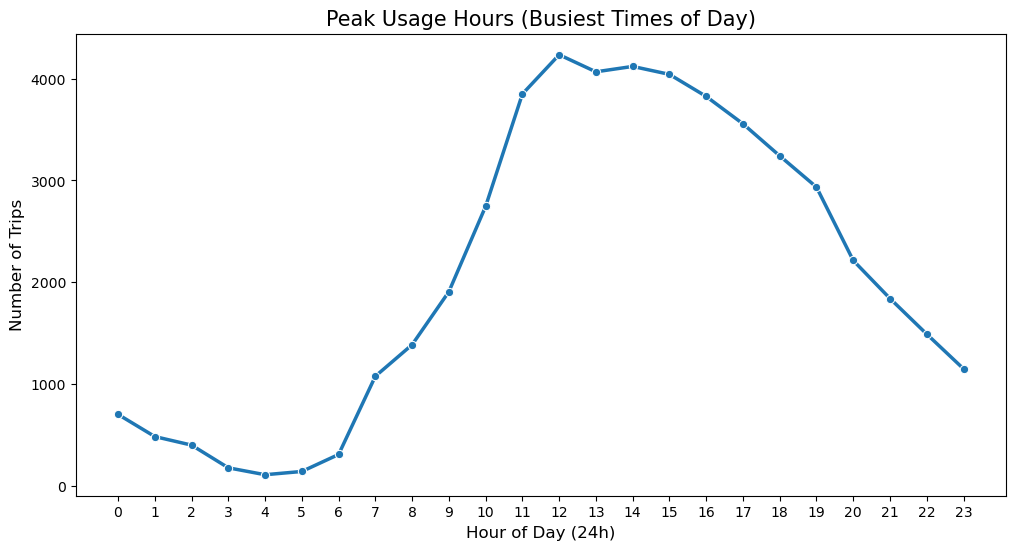

In [61]:
# Peak hours
peak_hours = df_clean.groupby('hour').size().reset_index(name='count')

# Visualise
plt.figure(figsize=(12, 6))
#sns.set_theme(style="whitegrid")

sns.lineplot(data=peak_hours, x='hour', y='count',  palette='mako', linewidth=2.5, marker='o')

plt.title('Peak Usage Hours (Busiest Times of Day)', fontsize=15)
plt.xticks(range(0,24))
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.show()

**Observation** : 

Rider usage begins to climb sharply at 7:00am, peakin at midday between 11:00am and 3:00pm. The busiest hour is 12:00pm(Noon). Usage is lowest between 1:00am and 5:00am

**Suggestion**: 

Ensuring extra bikes are made available just before the 11:00am could help reduce complaints of bike availabilty. Also, the low usage between 1:00am and 5:00am provides a good opportunity for system checks and bike repairs.


### Insight 2: Popular Stations

In [62]:
# Top 10 most popular start stations
top_stations = df_clean['start_station_name'].value_counts().head(10).reset_index()

top_stations

,start_station_name,count
0,11th and congress at the texas capitol,4456
1,21st and speedway at pcl,2248
2,11th and san jacinto,1785
3,12th and san jacinto at state capitol visitors...,1772
4,guadalupe and west mall at university co op,1318
5,21st and guadalupe,1311
6,11th and salina,1301
7,2nd and congress,1258
8,16th and san antonio,1207
9,4th and congress,1185


C:\Users\Leenaa\AppData\Local\Temp\ipykernel_20764\1201623445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stations, y='start_station_name', x='count', palette='mako')


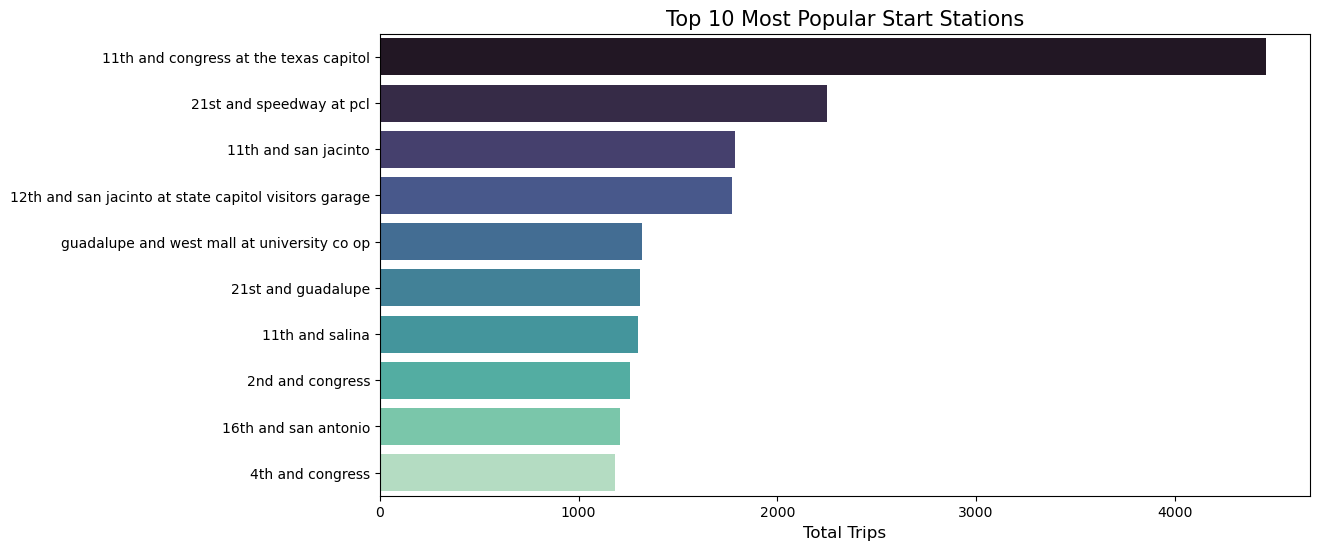

In [63]:
# Visualise the top 10 stations
plt.figure(figsize=(12, 6))

sns.barplot(data=top_stations, y='start_station_name', x='count', palette='mako')

plt.title('Top 10 Most Popular Start Stations', fontsize=15)
plt.xlabel('Total Trips', fontsize=12)
plt.ylabel('')
plt.show()

**Observation**: 

The station at ***11th and congress at the texas capitol*** is significantly more popular than other stations. Other popular locations include ***21st and speedway at pcl***, ***11th and san jacinto*** and ***12th at san jacinto at state capitol visitors garage*** are also quite popular.

**Suggestion** : 

These high-traffic stations should be prioritised for  routine maintenance, station expansions and adjusting efforts to ensure constant bike availability.

### Insight 3: How Different Riders Use the Service

In [65]:
# Rider patterns
# What type of riders take the most trips and what type take the longest trips on average
rider_pattern = df_clean.groupby('member_type')['trip_duration_min'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)

rider_pattern = rider_pattern.rename(columns={'count': 'No of Trips', 'mean': 'Average Trip Duration'})

rider_pattern

,No of Trips,Average Trip Duration
member_type,,
Annual Pass,5,157.800000
Heartland Pass (Annual Pay),1,151.000000
Single Trip,394,118.299492
Annual Member,5,98.800000
Single Trip,60,97.450000
Single Trip (Pay-as-you-ride),1527,86.996071
Single Trip Ride,74,86.040541
$1 Pay by Trip Winter Special,20,62.150000
HT Ram Membership,1246,60.211878


C:\Users\Leenaa\AppData\Local\Temp\ipykernel_20764\3686460590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Average Trip Duration", y="member_type", palette="mako")


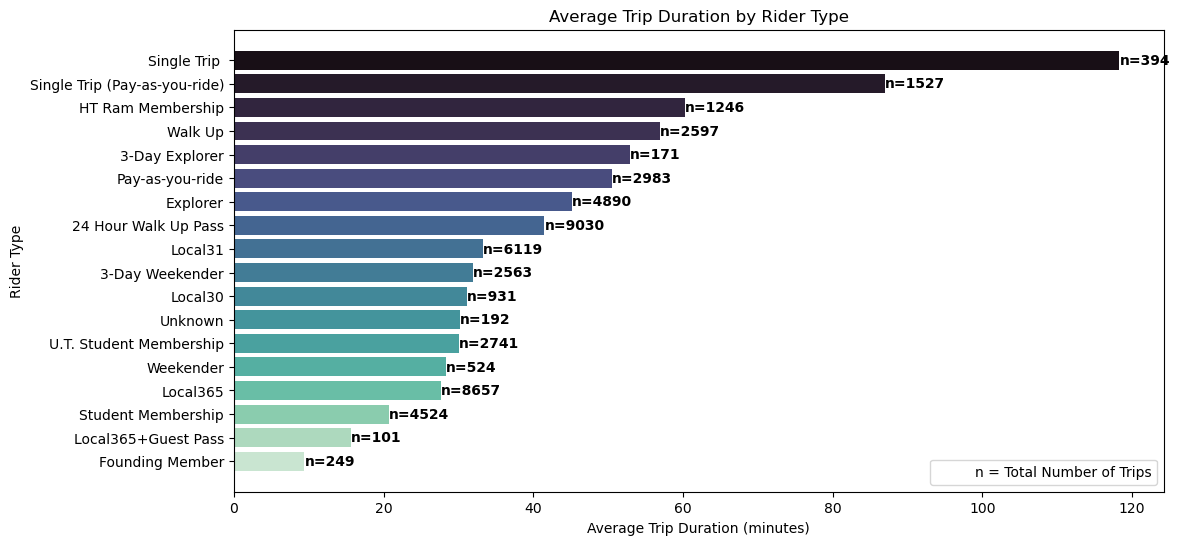

In [66]:
# Visualise rider pattern

# Filter for member_type with at least 100 trips
filtered_members = rider_pattern[rider_pattern['No of Trips'] >= 100]

# Convert the index back into a column for plotting
plot_data = filtered_members.reset_index()
plot_data


plt.figure(figsize=(12, 6))

sns.barplot(data=plot_data, x="Average Trip Duration", y="member_type", palette="mako")

plt.xlabel("Average Trip Duration (minutes)")
plt.ylabel("Rider Type")
plt.title("Average Trip Duration by Rider Type")

for i, row in plot_data.iterrows():
    plt.text(
        x =row["Average Trip Duration"],
        y = i,
        s = f'n={row["No of Trips"]}',
        va ='center',
        fontweight = 'bold'
    )

plt.plot([], [], ' ', label="n = Total Number of Trips")
plt.legend()

plt.show()

**Observation**: 

Analyzing average trip duration by membership type reveals clear differences in how various users interact with the service. Casual Subscribers(short-term users) tend to have much higher average trip durations compared to Annual Members(long-term users), while  Annual Members tend to take more trips. 

**Suggestion**: 

For long duration trips taken by casual subscribers, bikes should be optimized for comfort and long-distance reliability.For members who take shorter, more frequent trips, the focus should stay on making sure bikes are always available at the busiest transit spots.